# Welcome to RISK Advanced Quickstart

This notebook extends the basic quickstart to demonstrate that RISK separates topology inference from annotation enrichment. The same network structure and Louvain community assignments support multiple independent analyses.

We analyze the Costanzo et al. (2016) yeast genetic interaction (GI) network (3,641 genes, 23,562 interactions) using two annotation layers on the same topology:
- **GO Biological Process** defines the canonical functional scaffold via permutation-based enrichment
- **Tunicamycin chemical-genetic sensitivity** (Piotrowski et al., 2017) is projected onto that scaffold via hypergeometric localization

RISK separates three concerns: topology inference, functional enrichment, and external signal projection. The same Louvain communities are reused across analyses without recomputing the network structure.

You will learn how to:
- Load a network from a serialized NetworkX graph
- Compute Louvain communities once and reuse them across analyses
- Build a GO BP functional scaffold with permutation-based enrichment
- Load a perturbation annotation and test localization with the hypergeometric test
- Overlay a perturbation signal onto the GO BP scaffold

Expected input files in `data`:
- `gpickle/costanzo_2016_std_names.gpickle`
- `json/annotation/go_biological_process.json`
- `json/perturbation/piotrowski_2017_chem_gi.json`

For full API coverage and additional examples, see the [RISK documentation](https://riskportal.github.io/risk-docs/).

In [19]:
# Import RISK
import risk as r
from risk import RISK

# Import standard libraries
import json
import os
import pickle
from pathlib import Path

# Print RISK version
print(f"RISK version: {r.__version__}")

# Set working directory if running in a Binder / notebook environment
if "__file__" not in globals():
    os.chdir(Path().resolve())

# Enable inline plotting for notebooks
%matplotlib inline

# Shared random seed for reproducibility across both annotation layers
RANDOM_SEED = 887

RISK version: 0.1.3


---

## Initialize RISK

Initialize a `RISK` instance to run the analysis workflow and record parameters.


In [20]:
# Initialize RISK
risk = RISK(verbose=True)

---

## Load the network

Load the network from a serialized NetworkX graph using `load_network_networkx`. This approach accepts a pre-built graph object directly, which is useful when the network has already been processed and saved.


In [24]:
# Load the Costanzo 2016 GI network from a serialized NetworkX graph
with open("./data/gpickle/costanzo_2016.gpickle", "rb") as f:
    costanzo_gpickle = pickle.load(f)

network = risk.load_network_networkx(
    network=costanzo_gpickle,
    compute_sphere=False,
    surface_depth=0.1,
    min_edges_per_node=0,
)

---------------
Loading network
---------------
Filetype: NetworkX
Minimum edges per node: 0
Projection: Plane
3641 out of 3641 nodes (100.00%) were missing 'label' attributes and were assigned node IDs.
EDGE LENGTH WARNING — 152 out of 23714 edges (0.64%) had invalid or non-positive lengths and were replaced with a minimal fallback value (1e-12).
Initial node count: 3641
Final node count: 3641
Initial edge count: 23714
Final edge count: 23562


---

## Cluster the network

Run Louvain clustering to detect communities. The cluster assignments are computed once and reused for both the GO BP enrichment and the perturbation localization without recomputing the network structure.


In [29]:
# Detect Louvain communities — reused for both GO BP and perturbation analyses
clusters = risk.cluster_louvain(
    network=network,
    fraction_shortest_edges=0.25,
    resolution=2.0,
    random_seed=RANDOM_SEED,
)
print(f"Louvain clusters: shape={clusters.shape}, nnz={clusters.getnnz()}")

------------------
Computing clusters
------------------
Clustering: 'louvain'
Edge length threshold: 0.25
Resolution: 2.0
Random seed: 887
Louvain clusters: shape=(3641, 3641), nnz=59594


---

## Load GO BP annotations

Load GO Biological Process annotations and map them to network nodes. GO BP defines the canonical functional scaffold for the network.


In [30]:
# Load GO Biological Process (BP) annotations from a JSON file and associate with the network
annotation_bp = risk.load_annotation_json(
    network=network,
    filepath="./data/json/annotation/go_biological_process.json",
    min_nodes_per_term=1,
)

------------------
Loading annotation
------------------
Filetype: JSON
Filepath: ./data/json/annotation/go_biological_process.json
Minimum number of nodes per annotation term: 1
Maximum number of nodes per annotation term: 10000
Number of input annotation terms: 2214
Number of kept annotation terms: 2138


---

## Run GO BP enrichment

Evaluate GO BP annotation enrichment with the permutation test (`risk.run_permutation`).


In [35]:
# Compute GO BP enrichment via the permutation test
stats_bp = risk.run_permutation(
    annotation=annotation_bp,
    clusters=clusters,
    score_metric="stdev",
    null_distribution="network",
    num_permutations=1_000,  # Use 100 for quicker testing; increase for real analysis
    random_seed=RANDOM_SEED,
    max_workers=4,
)
print("Permutation test complete")

------------------------
Running permutation test
------------------------
Cluster scoring metric: 'stdev'
Number of permutations: 1000
Maximum workers: 4
Null distribution: 'network'


Total progress: 100%|██████████| 1000/1000 [00:17<00:00, 58.21it/s]

Permutation test complete


---

## Build the GO BP graph

Create a `Graph` object from the GO BP enrichment results. This object defines the canonical functional scaffold used for visualization and as the topology reference for the perturbation overlay.


In [36]:
# Generate the GO BP graph for analysis and visualization
graph_bp = risk.load_graph(
    network=network,
    annotation=annotation_bp,
    stats_results=stats_bp,
    tail="right",
    pval_cutoff=0.005,
    fdr_cutoff=1.00,
    display_prune_threshold=0.06,
    linkage_criterion="distance",
    linkage_method="single",
    linkage_metric="sokalsneath",
    linkage_threshold=0.001,
    min_cluster_size=8,
    max_cluster_size=1_000,
)

# Access key Graph attributes
domain_id_to_node_ids_map = graph_bp.domain_id_to_node_ids_map
domain_id_to_node_labels_map = graph_bp.domain_id_to_node_labels_map
domain_id_to_domain_terms_map = graph_bp.domain_id_to_domain_terms_map
node_label_to_significance_map = graph_bp.node_label_to_significance_map

----------------------------
Finding significant clusters
----------------------------
p-value cutoff: 0.005
FDR BH cutoff: 1.0
Significance tail: 'right' (enrichment)
-------------------------------
Processing significant clusters
-------------------------------
Display prune threshold: 0.06
-----------------------
Finding top annotations
-----------------------
Min cluster size: 8
Max cluster size: 1000
------------------------------
Grouping clusters into domains
------------------------------


Evaluating linkage methods and metrics: 100%|██████████| 1/1 [00:00<00:00]


Linkage criterion: 'distance'
Linkage method: 'single'
Linkage metric: 'sokalsneath'
Linkage threshold: 0.001


---

## Summarize GO BP results

Use `graph_bp.summary.load()` to generate a pandas DataFrame for domain-level result inspection.


In [37]:
# Load GO BP analysis summary into a DataFrame
loaded_summary = graph_bp.summary.load()
loaded_summary.head()

------------------------
Loading analysis summary
------------------------


,Domain ID,Annotation,Matched Members,Matched Count,Raw Enrichment P-value,Raw Enrichment Q-value,Raw Depletion P-value,Raw Depletion Q-value,Domain Enrichment P-value,Domain Enrichment Q-value,Domain Depletion P-value,Domain Depletion Q-value
0,-1,negative regulation of meiotic cell cycle phas...,,0,0.051,0.660836,0.900,1.0,1.0,1.0,1.0,1.0
1,-1,maintenance of protein location in cell,,0,0.001,0.057784,0.492,1.0,1.0,1.0,1.0,1.0
2,-1,positive regulation of G2/M transition of mito...,,0,1.000,1.000000,0.947,1.0,1.0,1.0,1.0,1.0
3,-1,negative regulation of pheromone-dependent sig...,,0,1.000,1.000000,0.936,1.0,1.0,1.0,1.0,1.0
4,-1,regulation of peroxisome organization,,0,0.001,0.801750,0.918,1.0,1.0,1.0,1.0,1.0


---

## Load tunicamycin perturbation data

Load chemical-genetic interaction data from Piotrowski et al. (2017) and define tunicamycin-sensitive genes as a single annotation term.


In [38]:
# Load Piotrowski chem-GI dataset and extract tunicamycin-sensitive genes
with open("./data/json/perturbation/piotrowski_2017_chem_gi.json") as f:
    chem_gi = json.load(f)

annotation_tuni = risk.load_annotation_dict(
    network=network,
    content={"Tunicamycin sensitive": chem_gi["Tunicamycin"]},
    min_nodes_per_term=1,
)

------------------
Loading annotation
------------------
Filetype: Dictionary
Filepath: In-memory dictionary
Minimum number of nodes per annotation term: 1
Maximum number of nodes per annotation term: 10000
Number of input annotation terms: 1
Number of kept annotation terms: 1


---

## Test perturbation localization

Test whether tunicamycin-sensitive genes are non-randomly concentrated within Louvain communities using the hypergeometric test. The same cluster assignments computed above are reused without modification.


In [39]:
# Compute tunicamycin localization significance via the hypergeometric test
stats_tuni = risk.run_hypergeom(
    annotation=annotation_tuni,
    clusters=clusters,
)
print("Hypergeometric test complete")

---------------------------
Running hypergeometric test
---------------------------
Null distribution: 'network'
Hypergeometric test complete


---

## Identify localized tunicamycin genes

Build the perturbation graph to identify Louvain communities significantly enriched for tunicamycin-sensitive genes, then extract the localized gene subset.


In [40]:
# Build the perturbation graph to identify enriched communities
graph_tuni = risk.load_graph(
    network=network,
    annotation=annotation_tuni,
    stats_results=stats_tuni,
    tail="right",
    pval_cutoff=0.05,
    fdr_cutoff=1.00,
    display_prune_threshold=0.0,
    linkage_criterion="off",
    min_cluster_size=1,
    max_cluster_size=1_000,
)

# Tunicamycin-sensitive genes in significantly enriched communities
tunicamycin_localized = sorted(
    set(chem_gi["Tunicamycin"])
    & {node for nodes in graph_tuni.domain_id_to_node_labels_map.values() for node in nodes}
)
print(f"Tunicamycin-sensitive genes in enriched regions: {len(tunicamycin_localized)}")

----------------------------
Finding significant clusters
----------------------------
p-value cutoff: 0.05
FDR BH cutoff: 1.0
Significance tail: 'right' (enrichment)
-------------------------------
Processing significant clusters
-------------------------------
Display prune threshold: 0.0
-----------------------
Finding top annotations
-----------------------
Min cluster size: 1
Max cluster size: 1000
------------------------------
Grouping clusters into domains
------------------------------
Clustering is turned off. Skipping clustering.
Tunicamycin-sensitive genes in enriched regions: 37


---

## Visualize the network

Render the GO BP functional scaffold with contours and domain labels, then overlay tunicamycin-sensitive genes in their significantly enriched territories.


---------------
Loading plotter
---------------


findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.
findfont: Font family 'Lato' not found.


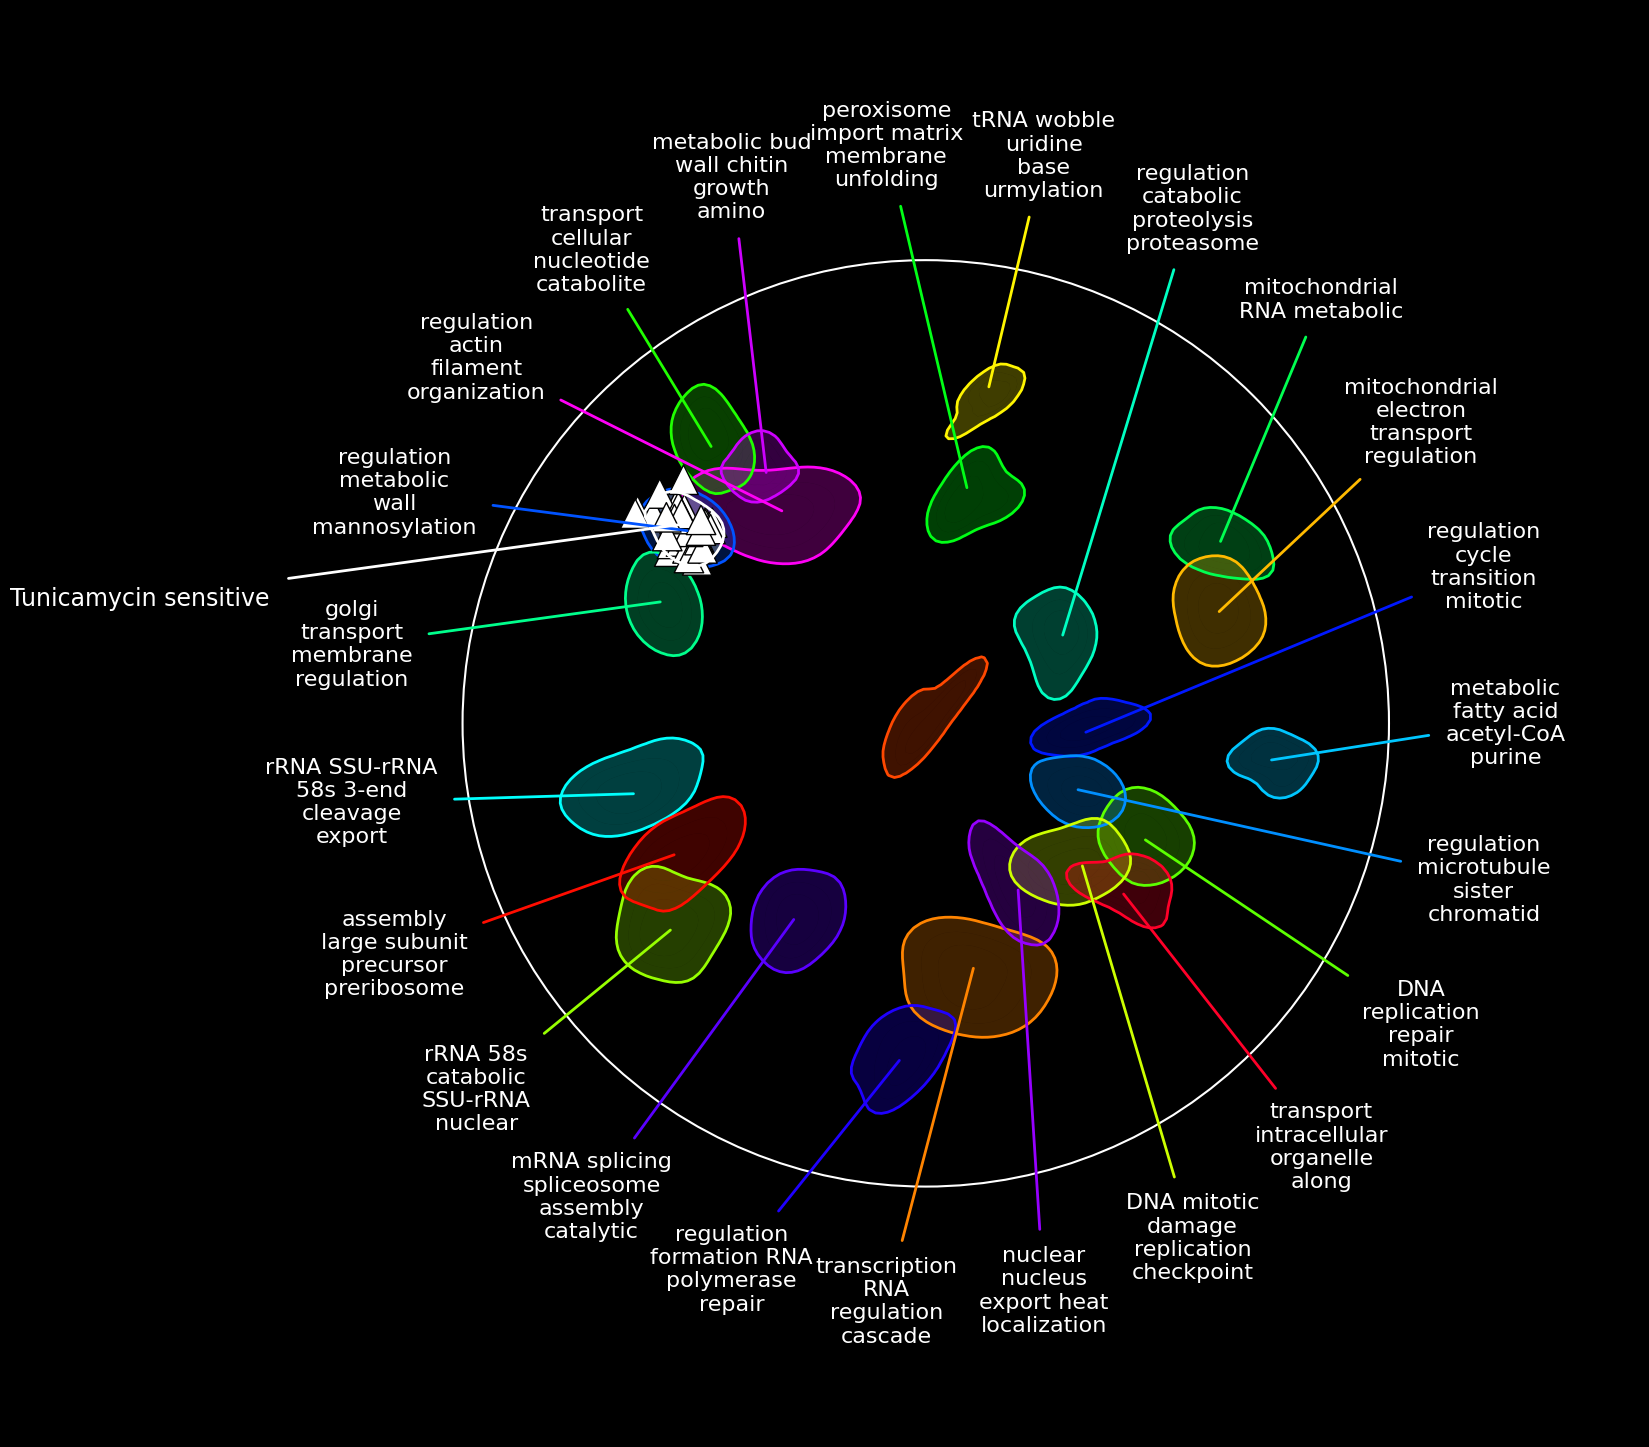

In [78]:
import matplotlib.pyplot as plt

# random_seed for plotting reproducibility (independent from RANDOM_SEED used for analysis)
random_seed = 877

# Initialize the Plotter with the GO BP graph
plotter = risk.load_plotter(
    graph=graph_bp,
    figsize=(15, 15),
    background_color="black",
)

# Plot network perimeter as a circle
plotter.plot_circle_perimeter(
    scale=1.02,
    center_offset_x=0.0,
    center_offset_y=0.0,
    linestyle="solid",
    linewidth=1.5,
    color="white",
    outline_alpha=1.0,
    fill_alpha=0.0,
)

# Plot KDE-based contours around network nodes
plotter.plot_contours(
    levels=5,
    bandwidth=0.8,
    grid_size=250,
    color=plotter.get_annotated_contour_colors(
        cmap="gist_rainbow",
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        ids_to_colors=None,
        random_seed=random_seed,
    ),
    linestyle="solid",
    linewidth=2.0,
    alpha=1.0,
    fill_alpha=0.25,
)

# Plot labels on the network
plotter.plot_labels(
    scale=1.1,
    offset=0.12,
    font="Lato",
    fontcase={"title": "lower"},
    fontsize=16,
    fontcolor="white",
    fontalpha=1.0,
    arrow_linewidth=2.0,
    arrow_style="-",
    arrow_color=plotter.get_annotated_label_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        ids_to_colors=None,
        random_seed=random_seed,
    ),
    arrow_alpha=1.0,
    arrow_base_shrink=10.0,
    arrow_tip_shrink=0.0,
    max_labels=50,
    min_label_lines=2,
    max_label_lines=4,
    min_chars_per_line=3,
    max_chars_per_line=13,
    words_to_omit=[
        "process",
        "cvt",
        "budding",
        "compound",
        "one-carbon",
        "response",
        "poly",
        "transduction",
        "generate",
        "involved",
        "cell",
        "between",
        "global",
        "biosynthetic",
        "positive",
        "negative",
        "protein",
        "complex",
        "changes",
        "cis",
    ],
    overlay_ids=False,
    ids_to_keep=None,
    ids_to_labels=None,
)

# Overlay tunicamycin-sensitive genes in their significantly enriched territories
plotter.plot_subnetwork(
    nodes=tunicamycin_localized,
    node_size=450,
    node_shape="^",
    node_edgewidth=1.0,
    edge_width=0.04,
    node_color="#ffffff",
    node_edgecolor="black",
    edge_color="#ffffff",
    node_alpha=1.0,
    edge_alpha=1.0,
)
plotter.plot_subcontour(
    nodes=tunicamycin_localized,
    levels=5,
    bandwidth=0.8,
    grid_size=250,
    color="#ffffff",
    linestyle="solid",
    linewidth=2.0,
    alpha=1.0,
    fill_alpha=0.25,
)
plotter.plot_sublabel(
    nodes=tunicamycin_localized,
    label="Tunicamycin sensitive",
    radial_position=279,
    scale=1.6,
    offset=0.12,
    font="Lato",
    fontsize=17,
    fontcolor="white",
    fontalpha=1.0,
    arrow_linewidth=2.0,
    arrow_style="-",
    arrow_color="#ffffff",
    arrow_alpha=1.0,
    arrow_base_shrink=30.0,
    arrow_tip_shrink=0.0,
)

# Display the plot
plotter.show()

---

## Review analysis parameters

Inspect `risk.params.load()` to review recorded settings for reproducibility and reporting.


In [ ]:
# Load and display analysis parameters
import pandas as pd
from IPython.display import display

loaded_params = risk.params.load()

# Display parameters in a tidy table
pd.set_option("display.max_colwidth", 200)
display(pd.DataFrame(list(loaded_params.items()), columns=["Parameter", "Value"]))
pd.reset_option("display.max_colwidth")